# World Cup 2026 attackers: efficiency, volume, and who actually carried

A debate I kept circling back to while rebuilding this chart was really a question of what a graph claims to show versus what it measures underneath, which I found compelling in the same way that comparing presidential approval polls from the past and now could be (LBJ compared to Biden, for example), where surface reading comes apart once you look closer. An approval rating looks like one clean measure, yet LBJ's slide and Biden's flat line are produced by completely different machinery underneath, one by events moving persuadable voters, the other by a polarization that pins the number in place almost regardless of events. Read them side by side and the metric you thought you understood turns out to be measuring two different things.

A football chart can do the same. This project starts from one popular but flawed attacker chart, rebuilds it honestly, and then argues that no single view is enough. To judge who actually carried a team you need two separate questions answered: how efficient a player was, and how much he did. This notebook builds both, states the shortfalls of each, and ranks the top five on each without forcing them into one number, because compositing the two hides the very trade-off that makes the comparison interesting.

## Part 1: the efficiency view

The chart I started with came from footballytics, plotting attackers on a blended vertical axis of 0.3 times goals plus 0.7 times xG per 90. Three problems made me rebuild it. The vertical axis was labeled finishing but a blend of goals and xG measures shot volume and chance quality, not finishing; real finishing is goals minus xG, the overperformance beyond what the chances predicted. It had no clean creation axis, so I used xA per 90, which credits chance quality and does not punish a creator whose teammates miss. And it weighted cameo samples the same as full tournaments, so I applied a 350-minute floor and sized every dot by minutes.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
INK,ACC,GOLD,MUT,GRID="#22303f","#3f6d9c","#c99a3b","#8a8f98","#e6e3db"
plt.rcParams.update({"font.size":11,"figure.facecolor":"white","axes.facecolor":"white"})
eff=pd.read_csv("wc2026_attackers.csv")
eff["fin_p90"]=(eff.goals-eff.xg_total)/eff.minutes*90
eff["xa_p90"]=eff.xa_total/eff.minutes*90
eff.sort_values("xa_p90",ascending=False).head()

,name,goals,xg_total,shots,xa_total,minutes,fin_p90,xa_p90
1,Messi,8,5.31,35,4.2,740,0.327162,0.510811
11,Olise,0,2.49,20,3.3,650,-0.344769,0.456923
16,Wirtz,0,0.97,10,1.7,363,-0.240496,0.421488
17,Madueke,0,0.61,6,1.6,364,-0.150824,0.395604
14,Trossard,2,1.75,17,2.2,510,0.044118,0.388235


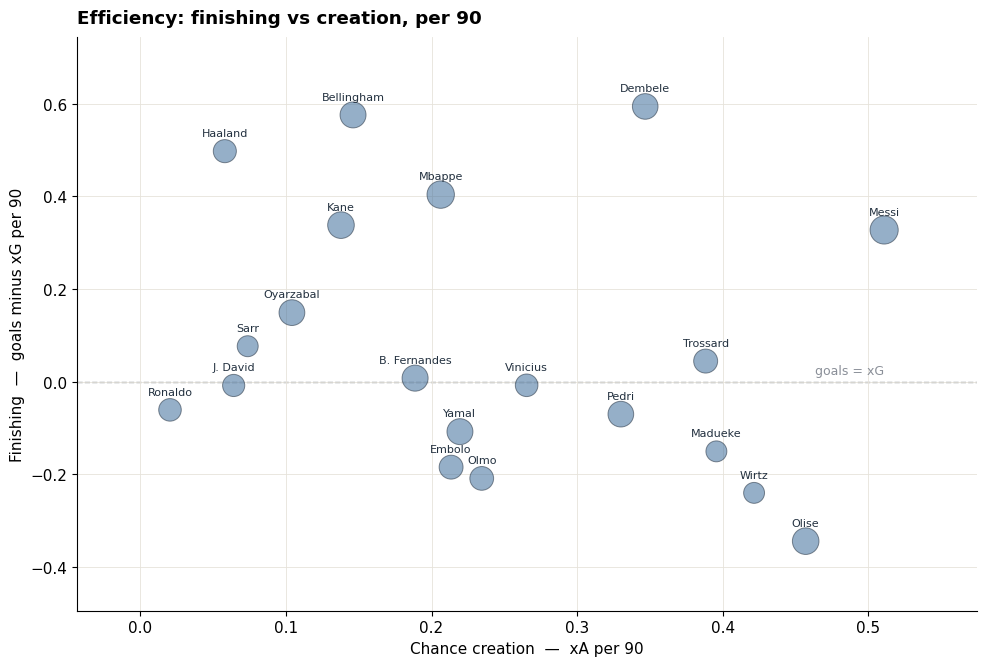

In [2]:
fig,ax=plt.subplots(figsize=(10,6.8))
sz=(eff.minutes/eff.minutes.max()*360)+50
ax.scatter(eff.xa_p90,eff.fin_p90,s=sz,color=ACC,alpha=.55,edgecolor=INK,lw=.7,zorder=3)
ax.axhline(0,color=MUT,lw=1,ls="--",zorder=1)
ax.text(eff.xa_p90.max(),.01,"goals = xG",color=MUT,fontsize=9,ha="right",va="bottom")
for _,r in eff.iterrows():
    ax.annotate(r["name"],(r.xa_p90,r.fin_p90),xytext=(0,11),textcoords="offset points",ha="center",fontsize=8,color=INK)
ax.set_xlabel("Chance creation  —  xA per 90"); ax.set_ylabel("Finishing  —  goals minus xG per 90")
ax.set_title("Efficiency: finishing vs creation, per 90",fontweight="bold",loc="left",pad=10)
ax.grid(color=GRID,lw=.6,zorder=0); ax.margins(x=.13,y=.16)
for s in["top","right"]:ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

Messi is the far-right creation outlier; on finishing he sits mid-pack, a good but not elite overperformer. Elite creator, solid finisher is the honest read. Dembele, on the other hand, was an incredible finisher and also displayed above average chance creation. Within these two statistics, the current Ballon-Dor holder and 8x total Ballon Dor holder are extremely contested, with perhaps Dembele holding the edge from face-value.

**Shortfalls of the efficiency view.** Rates reward a player who does a lot in limited time and cannot see workload. A substitute or rotation player who is rested between matches, or who enters against tired defences late in games, can post a strong per-90 rate on a light load that a starter grinding through 700 minutes cannot match. Per-90 also normalizes minutes away entirely, so it treats 350 and 700 minutes as equally trustworthy once past the floor, even though the longer sample is far more reliable. And finishing here rests on few shots per player, so most of these numbers carry wide uncertainty over a five-game tournament. Efficiency tells you the rate, not the burden carried to produce it.

## Part 1b: creation is not one skill

The efficiency chart uses xA to measure creation, but xA collapses a lot into one number. Creation has distinct facets, and different players lead different ones, which the single xA axis hides. This parallel-coordinates chart breaks creation into four per-90 metrics for the tournament's ten leading creators: chances created, crosses, through balls, and passes into the final third. Each axis is scaled to its own range, so a line that stays high across all four marks a complete, all-around creator; a line that spikes on one axis and drops on the others marks a specialist.

I included this deliberately, and it is the one view where Messi does not dominate. He is broad, high on chances created and crosses, but he is not the top on the progression metrics. Olise spikes on through balls, the tournament's best killer final ball, while sitting low on crosses. Pedri is the opposite shape, low on crosses and raw chances but far clear on final-third passes and strong on through balls, the deep progressor who moves the ball into danger rather than delivering the last pass. Reading these three lines against each other shows that "best creator" depends on which kind of creation you mean, and that honesty matters: a project where the same player wins every chart is a project that built its charts to a conclusion. This one does not.

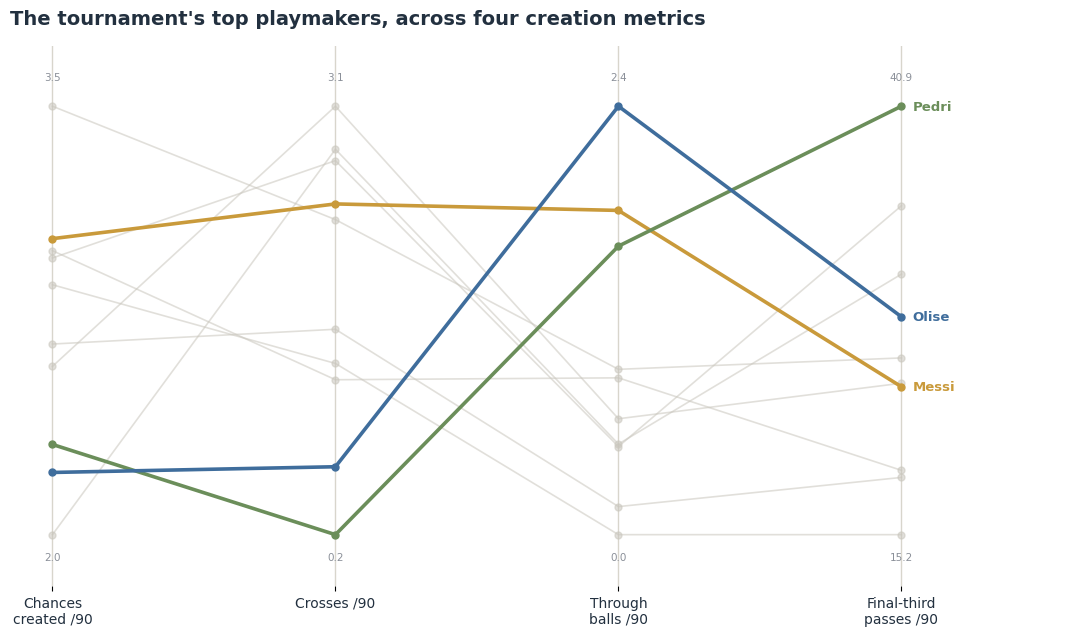

In [3]:
df=pd.read_csv("wc2026_playmaker_data.csv")
axes_m=["cc_90","cross_90","tb_90","f3_90"]
labels=["Chances\ncreated /90","Crosses /90","Through\nballs /90","Final-third\npasses /90"]
norm=df.copy()
for m in axes_m:
    norm[m]=(df[m]-df[m].min())/(df[m].max()-df[m].min())
highlight={"Messi":GOLD,"Olise":ACC,"Pedri":"#6b8e5a"}
GRAY="#c9c6bd"
fig,ax=plt.subplots(figsize=(11,6.5))
x=range(len(axes_m))
for _,r in norm.iterrows():
    y=[r[m] for m in axes_m]
    c=highlight.get(r["name"],GRAY)
    lw=2.6 if r["name"] in highlight else 1.2
    a=1.0 if r["name"] in highlight else .55
    z=5 if r["name"] in highlight else 2
    ax.plot(x,y,color=c,lw=lw,alpha=a,zorder=z,marker="o",markersize=5)
    if r["name"] in highlight:
        ax.text(len(axes_m)-1+.04,y[-1],r["name"],color=c,fontsize=9.5,fontweight="bold",va="center")
for i,m in enumerate(axes_m):
    ax.axvline(i,color="#d8d5cc",lw=1,zorder=1)
    ax.text(i,1.06,f"{df[m].max():.1f}",ha="center",fontsize=7.5,color=MUT)
    ax.text(i,-.06,f"{df[m].min():.1f}",ha="center",fontsize=7.5,color=MUT)
ax.set_xticks(x); ax.set_xticklabels(labels,fontsize=10,color=INK)
ax.set_yticks([]); ax.set_ylim(-.12,1.14); ax.set_xlim(-.15,len(axes_m)-.4)
ax.set_title("The tournament's top playmakers, across four creation metrics",fontweight="bold",fontsize=14,color=INK,loc="left",pad=16)
for s in ["top","right","left","bottom"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

## Part 2: the volume view

Efficiency cannot tell you who shouldered the load. For that you need raw totals: who actually generated the most for their team. This radar takes the top attacking contributor on each of the eight quarter-finalists and plots six raw volume metrics, each scaled to the group's maximum, so a fuller shape means more all-around output.

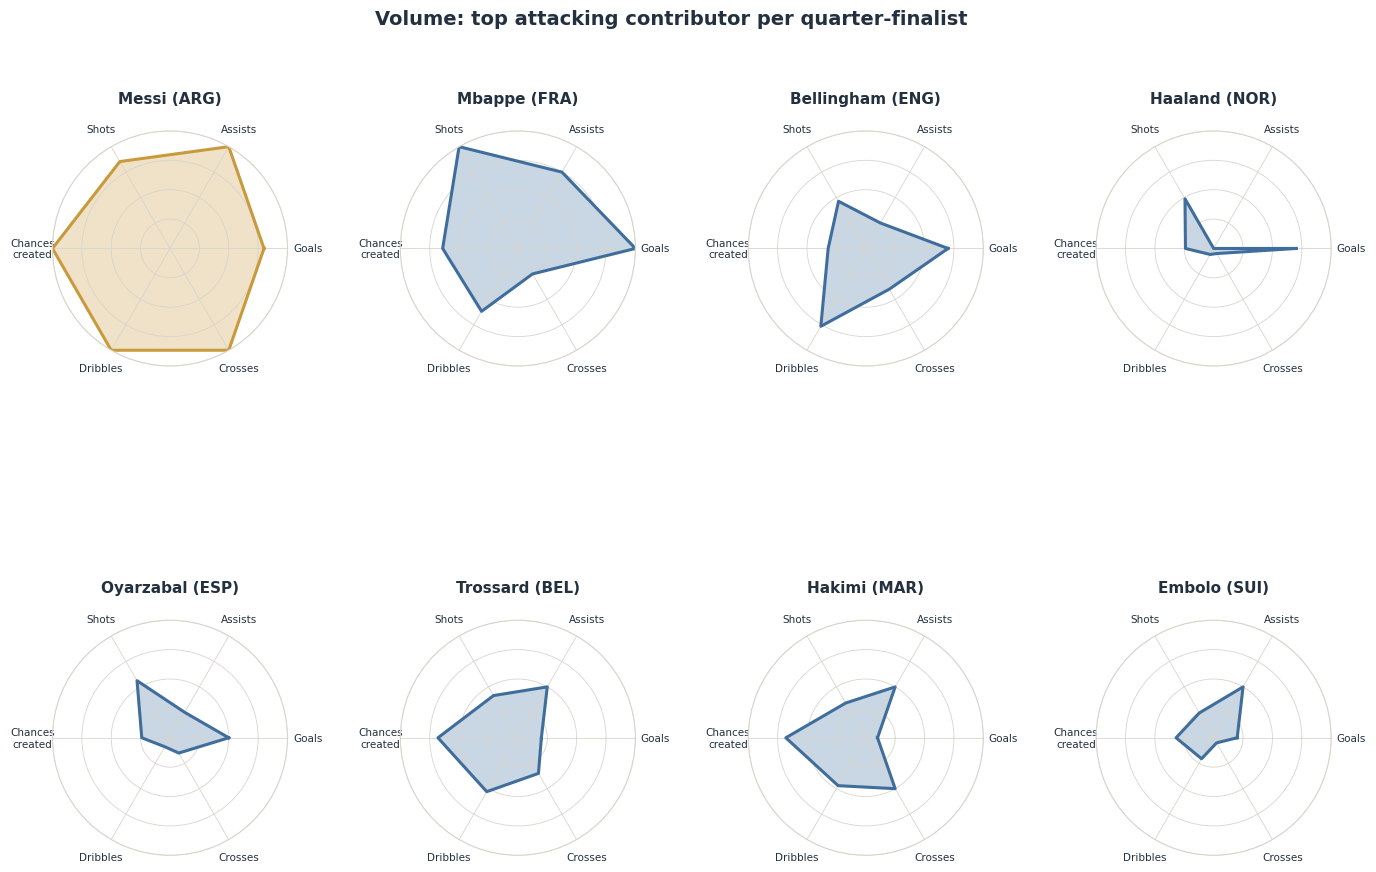

In [4]:
from math import pi
data={
 "Messi (ARG)":{"Goals":8,"Assists":4,"Shots":35,"Chances\ncreated":25,"Dribbles":3.4,"Crosses":20},
 "Mbappe (FRA)":{"Goals":10,"Assists":3,"Shots":41,"Chances\ncreated":16,"Dribbles":2.1,"Crosses":5},
 "Bellingham (ENG)":{"Goals":7,"Assists":1,"Shots":19,"Chances\ncreated":8,"Dribbles":2.6,"Crosses":8},
 "Haaland (NOR)":{"Goals":7,"Assists":0,"Shots":20,"Chances\ncreated":6,"Dribbles":0.2,"Crosses":1},
 "Oyarzabal (ESP)":{"Goals":5,"Assists":1,"Shots":23,"Chances\ncreated":6,"Dribbles":0.3,"Crosses":3},
 "Trossard (BEL)":{"Goals":2,"Assists":2,"Shots":17,"Chances\ncreated":17,"Dribbles":1.8,"Crosses":7},
 "Hakimi (MAR)":{"Goals":1,"Assists":2,"Shots":14,"Chances\ncreated":17,"Dribbles":1.6,"Crosses":10},
 "Embolo (SUI)":{"Goals":2,"Assists":2,"Shots":10,"Chances\ncreated":8,"Dribbles":0.7,"Crosses":1},
}
metrics=["Goals","Assists","Shots","Chances\ncreated","Dribbles","Crosses"]
maxes={m:max(d[m] for d in data.values()) for m in metrics}
fig,axes=plt.subplots(2,4,figsize=(16.5,9.4),subplot_kw=dict(polar=True))
angles=[n/len(metrics)*2*pi for n in range(len(metrics))]; angles+=angles[:1]
for ax,(name,d) in zip(axes.flat,data.items()):
    vals=[d[m]/maxes[m] for m in metrics]; vals+=vals[:1]
    col=GOLD if "Messi" in name else ACC
    ax.plot(angles,vals,color=col,lw=2.2); ax.fill(angles,vals,color=col,alpha=.28)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics,fontsize=7.5,color=INK)
    ax.set_yticks([.25,.5,.75,1.0]); ax.set_yticklabels([]); ax.set_ylim(0,1)
    ax.set_title(name,fontweight="bold",fontsize=11,color=INK,pad=20)
    ax.grid(color="#d8d5cc",lw=.6); ax.spines["polar"].set_color("#d8d5cc"); ax.tick_params(pad=4)
fig.suptitle("Volume: top attacking contributor per quarter-finalist",fontweight="bold",fontsize=14,y=.99,color=INK)
plt.subplots_adjust(hspace=.58,wspace=.48,top=.90,bottom=.05); plt.show()

Messi's shape is a near-full hexagon, strong on all six at once. Mbappe is large but tilted to goals and shots; the rest are smaller or spikier. On volume, Messi is the most complete.

**Shortfalls of the volume view.** Raw totals reward minutes and opportunity. A player on a ball-dominant side that goes deep accumulates more of everything simply by being on the pitch longer against more opponents, so volume partly measures team context and durability, not pure quality. It also does not adjust for efficiency: a high-volume shooter who converts poorly still posts big shot and chance totals, so a full radar can flatter a player who did a lot without doing it well, and crosses in particular reward repetition over quality. Volume tells you the burden carried, not how well it was carried.

## Part 3: the category leaderboards

Before ranking, the raw category leaders, top eight per metric, Messi highlighted. This shows breadth: who ranks high across many categories rather than spiking in one.

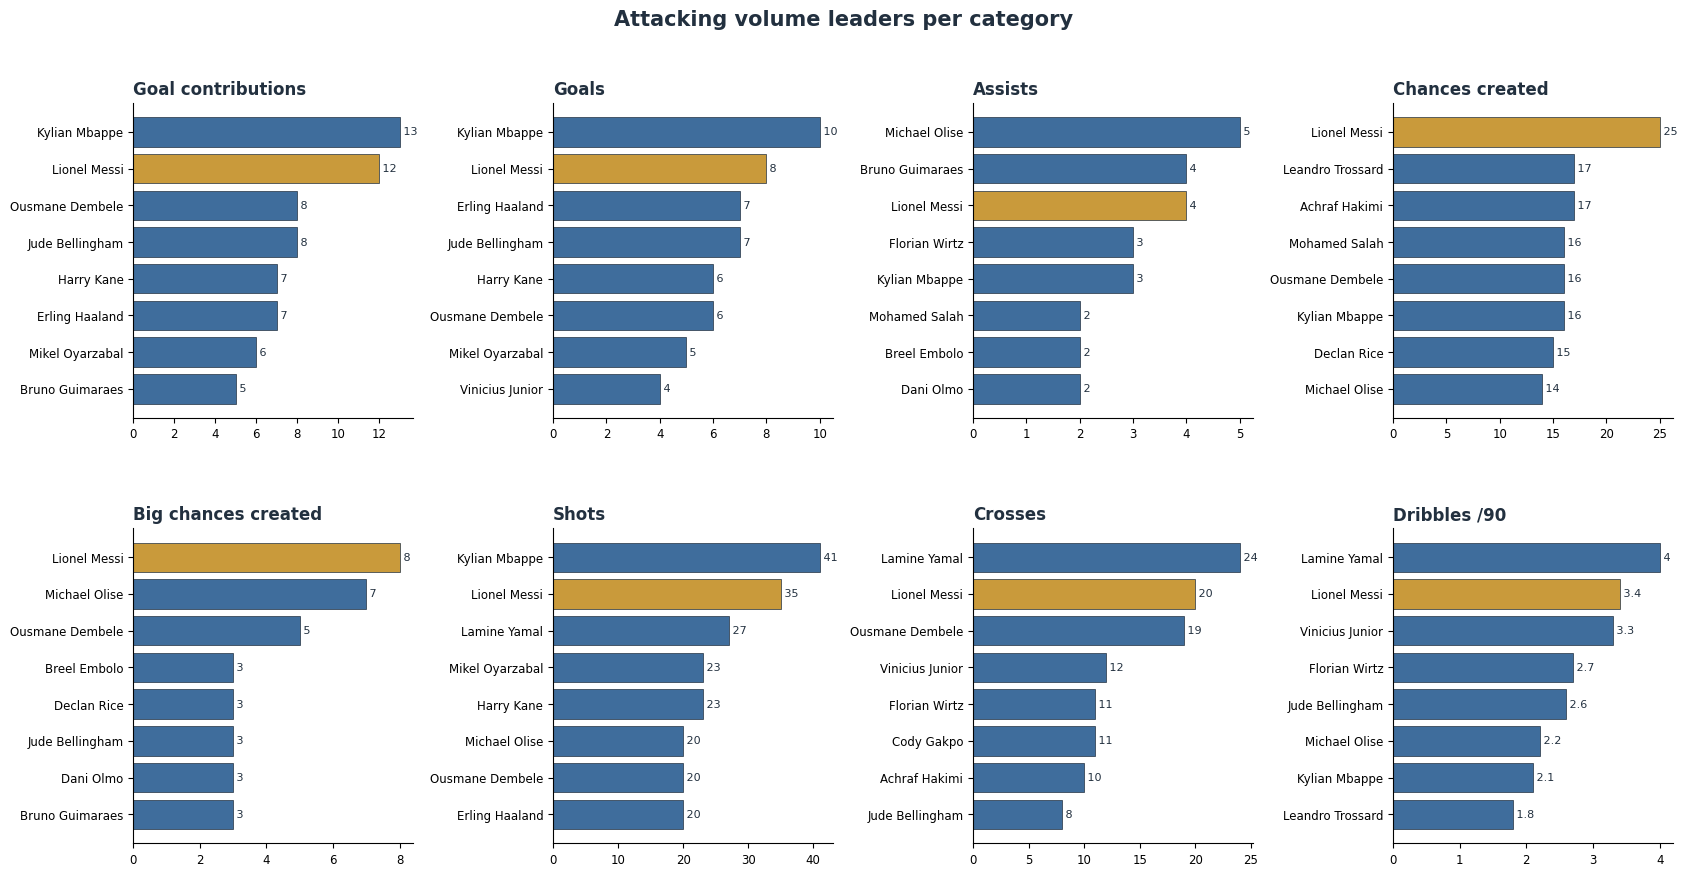

In [5]:
df=pd.read_csv("wc2026_volume_data.csv"); df["GA"]=df["G"]+df["A"]
cats=[("GA","Goal contributions"),("G","Goals"),("A","Assists"),("CC","Chances created"),
      ("bcc","Big chances created"),("shots","Shots"),("cross","Crosses"),("drib","Dribbles /90")]
fig,axes=plt.subplots(2,4,figsize=(17,9))
for ax,(col,title) in zip(axes.flat,cats):
    d=df.dropna(subset=[col]).sort_values(col).tail(8)
    colors=[GOLD if n=="Lionel Messi" else ACC for n in d["name"]]
    ax.barh(d["name"],d[col],color=colors,edgecolor=INK,lw=.5)
    ax.set_title(title,fontweight="bold",fontsize=12,color=INK,loc="left"); ax.tick_params(labelsize=8.5)
    for s in["top","right"]:ax.spines[s].set_visible(False)
    for i,v in enumerate(d[col]): ax.text(v,i,f" {v:g}",va="center",fontsize=8,color=INK)
fig.suptitle("Attacking volume leaders per category",fontweight="bold",fontsize=15,color=INK,y=.99)
plt.tight_layout(rect=[0,.02,1,.97]); plt.subplots_adjust(hspace=.35,wspace=.5); plt.show()

Messi is first in chances created (25, far clear) and big chances created, and top-three in every other category. No other attacker is that consistent across the board.

## Part 4: two rankings, not one

Carrying a team means both being efficient and doing a lot. Rather than merge those into a single score, which double-counts creation and forces an arbitrary weighting, I rank the top five on each separately. The efficiency ranking is per-90 (goal contribution and xA per 90); the volume ranking is totals (goal contributions, chances created, shots). Each uses non-overlapping metrics. The players who appear on both lists are the real standouts.

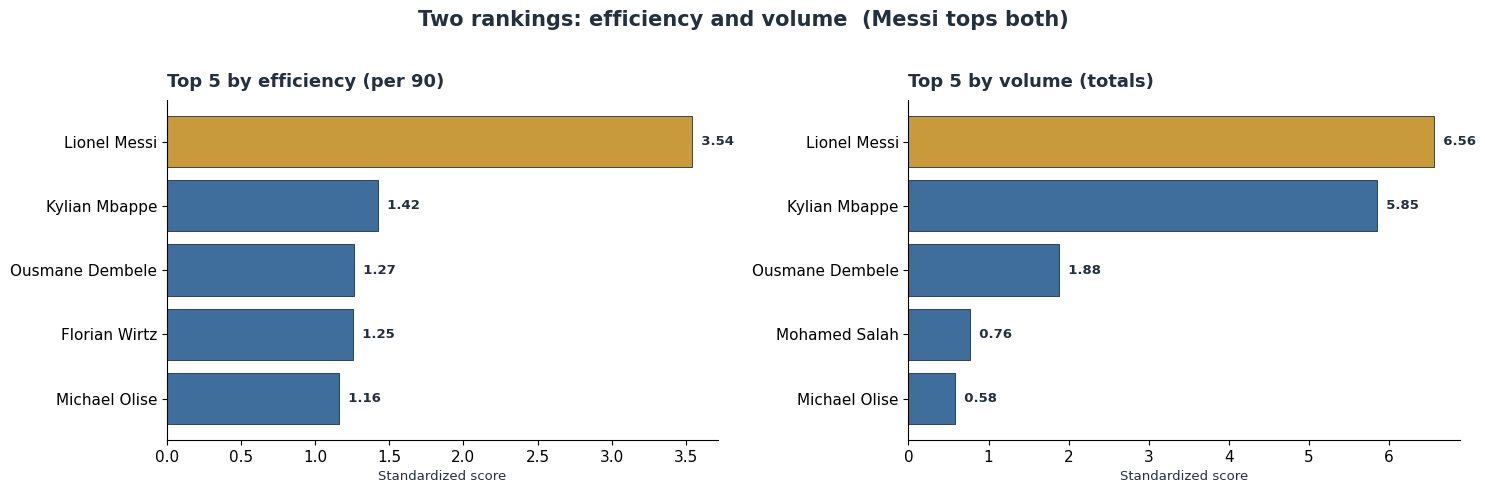

In [6]:
r=pd.read_csv("wc2026_rankings_data.csv")
eff5=r.sort_values("eff_rank_score",ascending=False).head(5).iloc[::-1]
vol5=r.sort_values("vol_rank_score",ascending=False).head(5).iloc[::-1]
fig,(a1,a2)=plt.subplots(1,2,figsize=(15,4.8))
for ax,d,col,title in [(a1,eff5,"eff_rank_score","Top 5 by efficiency (per 90)"),
                       (a2,vol5,"vol_rank_score","Top 5 by volume (totals)")]:
    colors=[GOLD if n=="Lionel Messi" else ACC for n in d["name"]]
    ax.barh(d["name"],d[col],color=colors,edgecolor=INK,lw=.6)
    for i,v in enumerate(d[col]): ax.text(v,i,f"  {v:.2f}",va="center",fontsize=9.5,color=INK,fontweight="bold")
    ax.set_title(title,fontweight="bold",fontsize=13,color=INK,loc="left",pad=10)
    ax.set_xlabel("Standardized score",fontsize=9.5,color=INK)
    for s in["top","right"]:ax.spines[s].set_visible(False)
fig.suptitle("Two rankings: efficiency and volume  (Messi tops both)",fontweight="bold",fontsize=15,color=INK,y=1.02)
plt.tight_layout(); plt.show()

Messi tops both lists, clearly. Four names appear on both, Messi, Mbappe, Dembele, and Olise, and those are the genuine standouts: strong on how-well and how-much at once. Mbappe is second on both, elite volume with solid efficiency. Players who appear on only one list did one thing: Wirtz rates on per-90 efficiency off limited minutes but drops out of the volume list; Salah posts volume without matching the efficiency leaders.

**Shortfall of the two-ranking approach.** Splitting into two lists avoids double-counting and forced weighting, but it still asks the reader to synthesize rather than handing over one answer, and the efficiency list inherits the per-90 problem, it rewards rate over durability, which is exactly why a low-minute creator like Wirtz appears there. The volume list corrects for that by rewarding accumulated output, which is why the two are shown together rather than alone.

## What I take from this

No single metric names who carried a team, and any chart that claims to is hiding a weighting. Efficiency and volume answer different questions, each with real blind spots: efficiency cannot see workload, volume cannot see quality. Read together they agree on one player. Messi led the tournament in creation efficiency, posted the most complete volume profile of any quarter-finalist's best man, and tops both the efficiency and volume rankings. Whether that makes him the best player of the tournament is a judgment no data settles, but that he carried Argentina, on both the how-well and the how-much, is the clearest thing the numbers say.

**Data note.** Finishing (goals, xG, shots): Opta / FIFA. Creation (xA, chances created), dribbles, big chances created: FotMob. Crosses: Opta. Efficiency figures use a 350-minute floor; volume figures use the top attacking contributor per quarter-finalist. Sample sizes are one tournament, so all rate-based figures carry real uncertainty, and the metric and weighting choices are stated so they can be challenged.